<h2>Klasifikasi Tingkat Kematangan Buah Pisang</h2>
<h3>PP1: Grayscale + Ekualisasi Histogram + Normalisasi</h3>
<h3>Ekstraksi Fitur GLCM | Klasifikasi: KNN, SVM, Random Forest</h3>


<h2>Import Library</h2>

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

print("Semua library berhasil diimport!")


Semua library berhasil diimport!


Library yang digunakan mencakup `cv2` untuk membaca dan mengkonversi citra, `numpy` dan `pandas` untuk manipulasi data, `matplotlib` untuk visualisasi. Ekstraksi fitur tekstur menggunakan `graycomatrix` dan `graycoprops` dari `skimage.feature`. Tiga model klasifikasi digunakan yaitu KNN, SVM, dan Random Forest dari `scikit-learn`.

<h2>Load Dataset</h2>

In [4]:
DATASET_DIR = "./valid"
CLASSES     = ["ripe", "rotten", "unripe"]
IMG_SIZE    = (128, 128)

def insertGambar(folder):
    data, filenames, path = [], [], []
    data_distribution = {}
    for label in sorted(os.listdir(folder)):
        label_path = os.path.join(folder, label)
        if not os.path.isdir(label_path):
            continue
        image_files = os.listdir(label_path)
        data_distribution[label] = len(image_files)
        print(label)
        count = 0
        for filename in tqdm(image_files):
            if count == 100:
                break
            img = cv2.imread(os.path.join(label_path, filename))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                img_gray = cv2.resize(img_gray, IMG_SIZE)
                filenames.append(filename)
                path.append(label)
                data.append(img_gray)
                count += 1
    return data, filenames, path, data_distribution

images, filenames, path, distribusi = insertGambar(DATASET_DIR)

print("\nJumlah gambar    :", len(images))
print("Jumlah label unik:", len(set(path)))
print("Distribusi data  :", distribusi)


ripe


100%|██████████| 70/70 [00:00<00:00, 1118.54it/s]


rotten


100%|██████████| 70/70 [00:00<00:00, 1133.67it/s]


unripe


100%|██████████| 70/70 [00:00<00:00, 1283.45it/s]


Jumlah gambar    : 210
Jumlah label unik: 3
Distribusi data  : {'ripe': 70, 'rotten': 70, 'unripe': 70}


Fungsi `insertGambar()` memuat gambar dari setiap subfolder dalam `dataset_sampled/`. Setiap gambar dibaca menggunakan `cv2.imread`, dikonversi ke grayscale dengan `cv2.cvtColor`, lalu di-resize ke 128×128 piksel. Jumlah gambar dibatasi 100 per kelas.

<h2>Data Understanding</h2>

Distribusi Data (Bar Chart)

kode ini memvisualisasikan distribusi jumlah gambar per kelas dalam bentuk diagram batang berwarna menggunakan matplotlib. Setiap batang diberi anotasi angka di bagian atasnya agar jumlah gambar per kelas mudah dibaca, dan grafik dilengkapi dengan judul, label sumbu X dan Y, serta tata letak yang rapi menggunakan tight_layout().

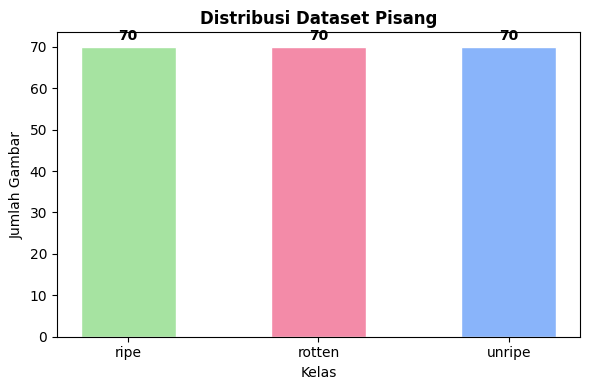

In [5]:
label_names = list(distribusi.keys())
jumlah      = list(distribusi.values())
colors      = ["#a6e3a1", "#f38ba8", "#89b4fa"]

plt.figure(figsize=(6, 4))
bars = plt.bar(label_names, jumlah, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, jumlah):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha="center", va="bottom", fontweight="bold")
plt.title("Distribusi Dataset Pisang", fontweight="bold")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()


---

Sampel Gambar Grayscale

kode ini menampilkan 10 sampel gambar grayscale untuk masing-masing kelas dalam grid 3 baris × 10 kolom menggunakan plt.subplots(). Baris pertama menampilkan gambar kelas ripe, baris kedua rotten, dan baris ketiga unripe, dengan label kelas ditampilkan pada kolom pertama setiap baris sebagai referensi visual awal terhadap isi dataset.

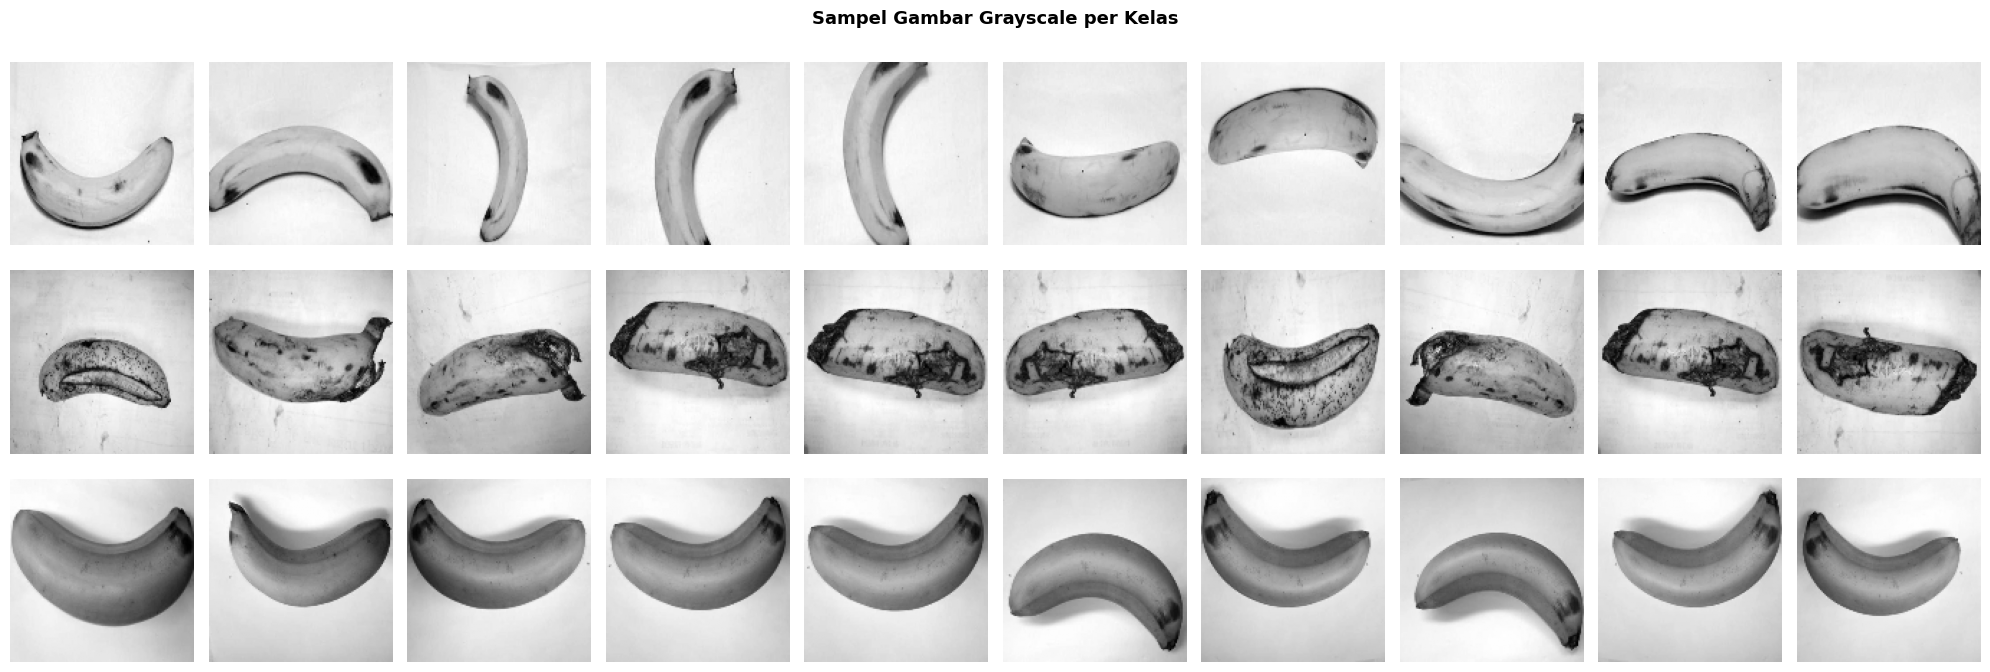

In [6]:
fig, axes = plt.subplots(3, 10, figsize=(20, 7))
fig.suptitle("Sampel Gambar Grayscale per Kelas", fontsize=13, fontweight="bold")

for row, cls in enumerate(CLASSES):
    cls_imgs = [img for img, lbl in zip(images, path) if lbl == cls][:10]
    for col, img in enumerate(cls_imgs):
        axes[row][col].imshow(img, cmap="gray")
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


---

<h1>Preprocessing 1: Grayscale + Ekualisasi Histogram + Normalisasi</h1>

<h2>Fungsi Ekualisasi Histogram</h2>

In [7]:
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = 0
    for i in range(256):
        if cdf[i] > 0:
            cdf_min = cdf[i]
            break
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

print("Fungsi ekualisasi_histogram siap!")


Fungsi ekualisasi_histogram siap!


Fungsi `ekualisasi_histogram()` bekerja dengan 3 tahap:
1. **Hitung histogram** — menghitung frekuensi kemunculan tiap nilai intensitas (0-255)
2. **Hitung CDF** (Cumulative Distribution Function) — akumulasi histogram untuk mengetahui distribusi intensitas
3. **Normalisasi & Pemetaan** — CDF dinormalisasi ke rentang [0, 255] lalu setiap piksel dipetakan ke nilai baru, menghasilkan citra dengan kontras yang lebih merata

<h2>Fungsi Normalisasi</h2>

In [8]:
def normalisasi(citra):
    panjang, lebar = citra.shape
    hasil = np.zeros_like(citra, dtype=np.float32)
    min_val = np.min(citra)
    max_val = np.max(citra)
    for i in range(panjang):
        for j in range(lebar):
            hasil[i, j] = (citra[i, j] - min_val) / (max_val - min_val) * 255
    return hasil.astype(np.uint8)

print("Fungsi normalisasi siap!")


Fungsi normalisasi siap!


Fungsi `normalisasi()` memetakan nilai piksel ke rentang [0, 255] menggunakan rumus min-max normalization: `(x - min) / (max - min) * 255`. Ini memastikan seluruh rentang intensitas dimanfaatkan secara optimal setelah ekualisasi histogram.

<h2>Fungsi Preprocessing 1</h2>

In [9]:
def preprocessing_1(img_gray):
    """
    PP1: Ekualisasi Histogram → Normalisasi
    (Grayscale sudah dilakukan saat load gambar)
    """
    equalized  = ekualisasi_histogram(img_gray)
    normalized = normalisasi(equalized)
    return normalized

print("Fungsi preprocessing_1 siap!")


Fungsi preprocessing_1 siap!


### Fungsi preprocessing_1()

kode ini mendefinisikan fungsi pipeline Preprocessing 1 (PP1) yang menggabungkan dua tahap sebelumnya secara berurutan: pertama ekualisasi histogram untuk meningkatkan kontras, lalu normalisasi untuk menyeragamkan rentang nilai piksel. Catatan bahwa konversi ke grayscale sudah dilakukan lebih awal saat proses loading dataset, sehingga fungsi ini hanya menerima citra grayscale sebagai input.

<h2>Preview Hasil PP1</h2>

kode ini menampilkan perbandingan visual sebelum dan sesudah PP1 untuk satu sampel gambar dari masing-masing kelas dalam grid 3 baris × 2 kolom — kolom kiri menampilkan gambar grayscale asli dan kolom kanan menampilkan hasil setelah ekualisasi histogram dan normalisasi. Hasil visualisasi juga disimpan ke file preview_pp1.png untuk dokumentasi.


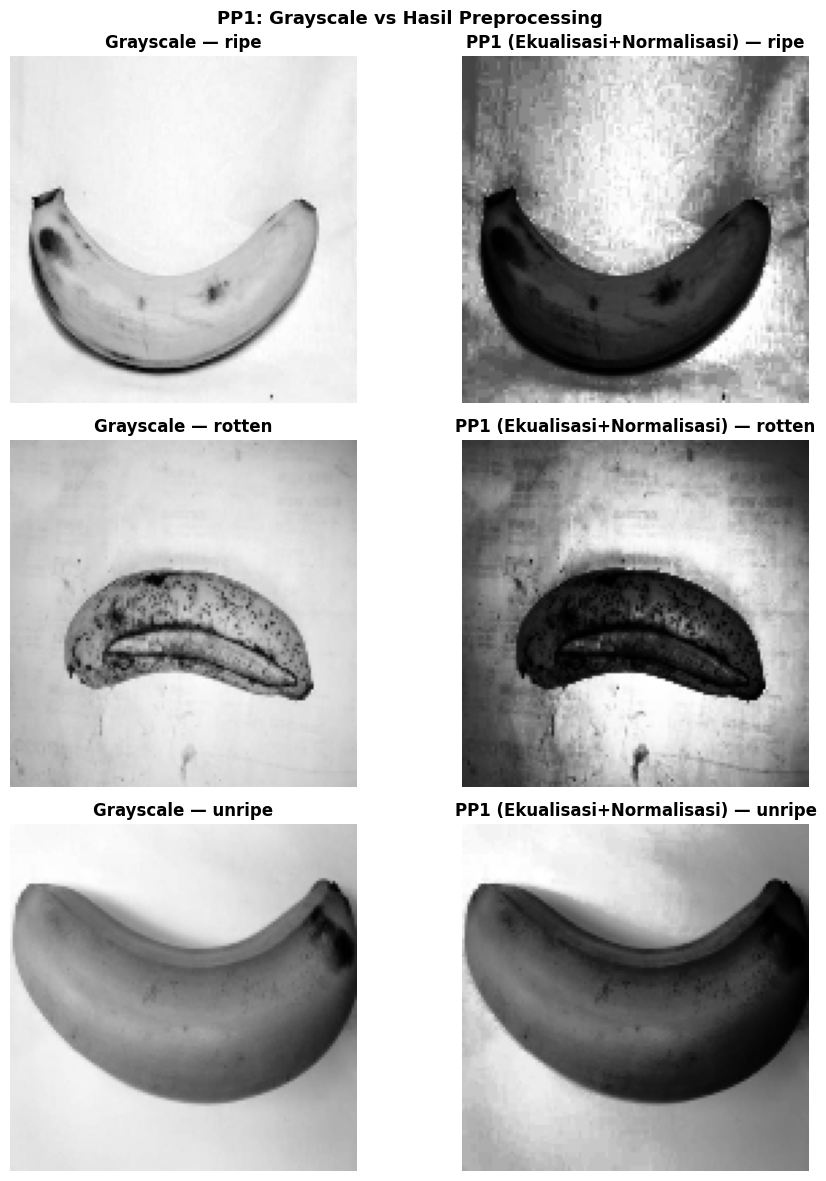

Preview tersimpan sebagai preview_pp1.png


In [10]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle("PP1: Grayscale vs Hasil Preprocessing", fontsize=13, fontweight="bold")

for row, cls in enumerate(CLASSES):
    sample = next(img for img, lbl in zip(images, path) if lbl == cls)
    pp1    = preprocessing_1(sample)

    axes[row][0].imshow(sample, cmap="gray")
    axes[row][0].set_title(f"Grayscale — {cls}", fontweight="bold")
    axes[row][0].axis("off")

    axes[row][1].imshow(pp1, cmap="gray")
    axes[row][1].set_title(f"PP1 (Ekualisasi+Normalisasi) — {cls}", fontweight="bold")
    axes[row][1].axis("off")

plt.tight_layout()
plt.savefig("preview_pp1.png", dpi=120, bbox_inches="tight")
plt.show()
print("Preview tersimpan sebagai preview_pp1.png")


---

<h2>Terapkan PP1 ke Seluruh Dataset</h2>

In [11]:
data_pp1 = []
for img in tqdm(images, desc="Menerapkan PP1"):
    data_pp1.append(preprocessing_1(img))

print(f"Total gambar terpreprocessing: {len(data_pp1)}")


Menerapkan PP1: 100%|██████████| 210/210 [00:04<00:00, 42.60it/s]

Total gambar terpreprocessing: 210


### Terapkan PP1 ke Seluruh Dataset

kode ini menerapkan fungsi preprocessing_1() ke seluruh gambar dalam dataset menggunakan loop dengan progress bar tqdm, menyimpan hasilnya ke list data_pp1. Setelah loop selesai, ditampilkan jumlah total gambar yang telah diproses sebagai konfirmasi bahwa preprocessing berhasil diterapkan ke semua data.

### Tampilkan Semua Gambar PP1

kode ini menampilkan seluruh gambar hasil PP1 (hingga 300 gambar) dalam satu grid besar berukuran 20 kolom menggunakan plt.subplots(). Jumlah baris dihitung secara dinamis berdasarkan jumlah gambar, dan setiap gambar ditampilkan tanpa sumbu agar visualisasi grid terlihat bersih dan kompak untuk inspeksi keseluruhan dataset.

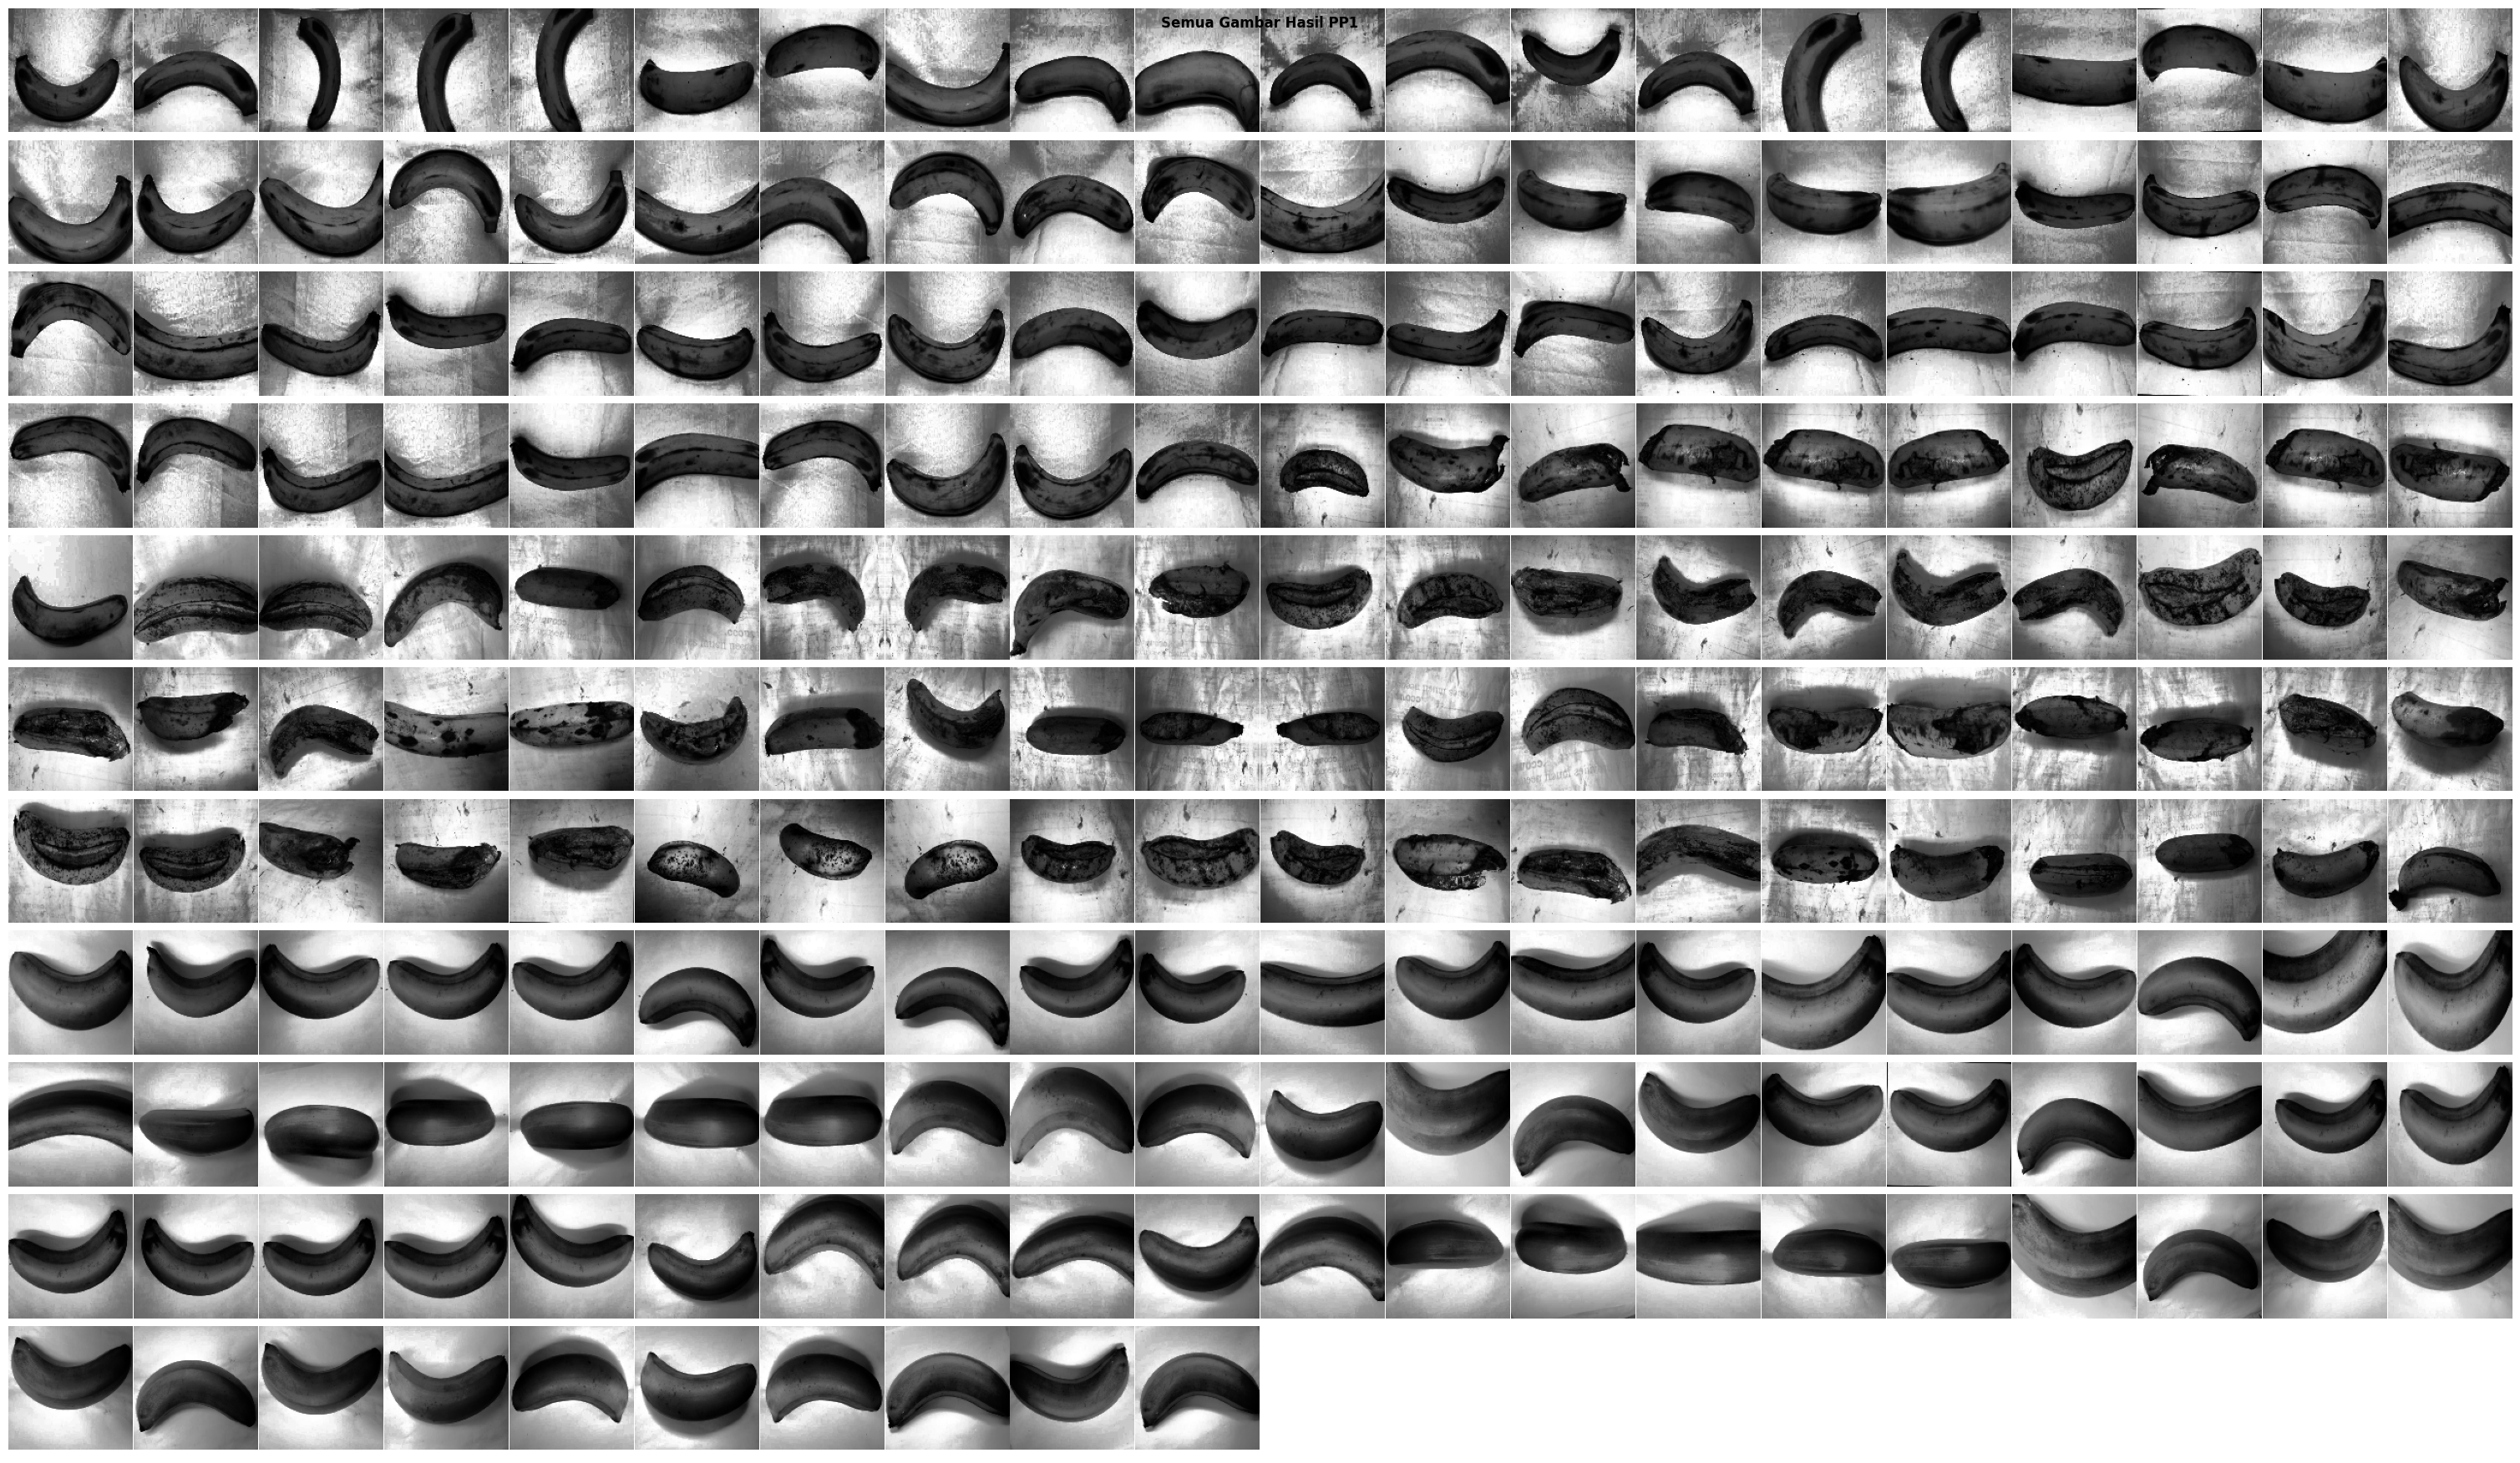

In [12]:
num_images = min(len(data_pp1), 300)
cols = 20
rows = (num_images // cols) + (1 if num_images % cols else 0)

fig, axes = plt.subplots(rows, cols, figsize=(30, rows * 1.6))
fig.suptitle("Semua Gambar Hasil PP1", fontsize=12, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(data_pp1[i], cmap="gray")
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout(pad=0.1)
plt.show()


<h1>Feature Extraction: Gray Level Co-occurrence Matrix (GLCM)</h1>

In [13]:
def glcm(image, derajat):
    if derajat == 0:      angles = [0]
    elif derajat == 45:   angles = [np.pi / 4]
    elif derajat == 90:   angles = [np.pi / 2]
    elif derajat == 135:  angles = [3 * np.pi / 4]
    else: raise ValueError("Sudut harus 0, 45, 90, atau 135")
    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

def contrast(m):      return graycoprops(m, 'contrast')[0, 0]
def dissimilarity(m): return graycoprops(m, 'dissimilarity')[0, 0]
def homogenity(m):    return graycoprops(m, 'homogeneity')[0, 0]
def ASM(m):           return graycoprops(m, 'ASM')[0, 0]
def energy(m):        return graycoprops(m, 'energy')[0, 0]
def correlation(m):   return graycoprops(m, 'correlation')[0, 0]
def entropyGlcm(m):   return entropy(m.ravel())

print("Fungsi GLCM siap!")


Fungsi GLCM siap!


Fungsi `glcm()` menghasilkan matriks co-occurrence dari citra grayscale pada sudut 0°, 45°, 90°, dan 135° menggunakan `graycomatrix` dengan jarak piksel 1, simetris, dan ternormalisasi. Tujuh fitur diekstraksi dari setiap matriks: **contrast**, **dissimilarity**, **homogeneity**, **ASM**, **energy**, **correlation**, dan **entropy** — menghasilkan total **28 fitur** per gambar.

<h2>Hitung Matriks GLCM</h2>

In [14]:
Derajat0, Derajat45, Derajat90, Derajat135 = [], [], [], []

for img in tqdm(data_pp1, desc="Menghitung GLCM"):
    Derajat0.append(glcm(img, 0))
    Derajat45.append(glcm(img, 45))
    Derajat90.append(glcm(img, 90))
    Derajat135.append(glcm(img, 135))

print(f"GLCM dihitung untuk {len(Derajat0)} gambar pada 4 sudut")


Menghitung GLCM: 100%|██████████| 210/210 [00:00<00:00, 586.27it/s]

GLCM dihitung untuk 210 gambar pada 4 sudut


### Hitung Matriks GLCM

kode ini menghitung matriks GLCM untuk setiap gambar hasil PP1 pada keempat arah sudut (0°, 45°, 90°, 135°) menggunakan loop dengan progress bar tqdm. Hasil matriks untuk masing-masing sudut disimpan dalam list terpisah (Derajat0, Derajat45, Derajat90, Derajat135) yang nantinya akan digunakan sebagai dasar ekstraksi fitur tekstur.


<h2>Ekstraksi Fitur dari GLCM</h2>

In [15]:
Kontras0,       Kontras45,       Kontras90,       Kontras135       = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135  = [], [], [], []
homogenity0,    homogenity45,    homogenity90,    homogenity135     = [], [], [], []
ASM0,           ASM45,           ASM90,           ASM135            = [], [], [], []
energy0,        energy45,        energy90,        energy135         = [], [], [], []
correlation0,   correlation45,   correlation90,   correlation135    = [], [], [], []
entropy0,       entropy45,       entropy90,       entropy135        = [], [], [], []

for i in range(len(data_pp1)):
    for D, K, Dis, H, A, En, Cor, Ent in [
        (Derajat0,   Kontras0,   dissimilarity0,   homogenity0,  ASM0,   energy0,   correlation0,   entropy0),
        (Derajat45,  Kontras45,  dissimilarity45,  homogenity45, ASM45,  energy45,  correlation45,  entropy45),
        (Derajat90,  Kontras90,  dissimilarity90,  homogenity90, ASM90,  energy90,  correlation90,  entropy90),
        (Derajat135, Kontras135, dissimilarity135, homogenity135,ASM135, energy135, correlation135, entropy135),
    ]:
        m = D[i]
        K.append(contrast(m))
        Dis.append(dissimilarity(m))
        H.append(homogenity(m))
        A.append(ASM(m))
        En.append(energy(m))
        Cor.append(correlation(m))
        Ent.append(entropyGlcm(m))

print("Ekstraksi fitur selesai!")
print("Jumlah Kontras0     :", len(Kontras0),       len(Kontras45),       len(Kontras90),       len(Kontras135))
print("Jumlah Homogeneity0 :", len(homogenity0),    len(homogenity45),    len(homogenity90),    len(homogenity135))
print("Jumlah Dissimilarity:", len(dissimilarity0), len(dissimilarity45), len(dissimilarity90), len(dissimilarity135))
print("Jumlah Entropy0     :", len(entropy0),       len(entropy45),       len(entropy90),       len(entropy135))
print("Jumlah ASM0         :", len(ASM0),           len(ASM45),           len(ASM90),           len(ASM135))
print("Jumlah Energy0      :", len(energy0),        len(energy45),        len(energy90),        len(energy135))
print("Jumlah Correlation0 :", len(correlation0),   len(correlation45),   len(correlation90),   len(correlation135))


Ekstraksi fitur selesai!
Jumlah Kontras0     : 210 210 210 210
Jumlah Homogeneity0 : 210 210 210 210
Jumlah Dissimilarity: 210 210 210 210
Jumlah Entropy0     : 210 210 210 210
Jumlah ASM0         : 210 210 210 210
Jumlah Energy0      : 210 210 210 210
Jumlah Correlation0 : 210 210 210 210


### Ekstraksi Fitur dari GLCM

kode ini mengekstrak ketujuh fitur tekstur (contrast, dissimilarity, homogeneity, ASM, energy, correlation, entropy) dari setiap matriks GLCM pada keempat sudut, menggunakan struktur loop bersarang yang efisien dengan bantuan list of tuples. Setiap kombinasi gambar dan sudut menghasilkan satu nilai per fitur, sehingga total terdapat 28 fitur per gambar (7 fitur × 4 sudut) yang tersimpan dalam list terpisah.

<h2>Buat DataFrame & Simpan ke CSV</h2>

In [16]:
df_pp1 = pd.DataFrame({
    "Filename": filenames, "Label": path,
    "Contrast0": Kontras0,       "Contrast45": Kontras45,       "Contrast90": Kontras90,       "Contrast135": Kontras135,
    "Dissimilarity0": dissimilarity0, "Dissimilarity45": dissimilarity45,
    "Dissimilarity90": dissimilarity90, "Dissimilarity135": dissimilarity135,
    "Homogeneity0": homogenity0,  "Homogeneity45": homogenity45,
    "Homogeneity90": homogenity90,"Homogeneity135": homogenity135,
    "ASM0": ASM0, "ASM45": ASM45, "ASM90": ASM90, "ASM135": ASM135,
    "Energy0": energy0,    "Energy45": energy45,    "Energy90": energy90,    "Energy135": energy135,
    "Correlation0": correlation0, "Correlation45": correlation45,
    "Correlation90": correlation90, "Correlation135": correlation135,
    "Entropy0": entropy0,  "Entropy45": entropy45,  "Entropy90": entropy90,  "Entropy135": entropy135,
})

df_pp1.to_csv("fitur_glcm_pp1.csv", index=False)
print(f"DataFrame shape: {df_pp1.shape}")
print(f"Tersimpan ke fitur_glcm_pp1.csv")
df_pp1.head()


DataFrame shape: (210, 30)
Tersimpan ke fitur_glcm_pp1.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Dissimilarity0,Dissimilarity45,Dissimilarity90,Dissimilarity135,...,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135,Entropy0,Entropy45,Entropy90,Entropy135
0,musa-acuminata-freshripe-43de8667-2653-11ec-a9...,ripe,363.876353,541.381115,285.435285,445.996218,10.791339,13.654535,9.357283,13.044640,...,0.104060,0.085618,0.968525,0.953290,0.975218,0.961519,5.674460,5.875830,5.602737,5.860942
1,musa-acuminata-freshripe-442acb3c-2653-11ec-a0...,ripe,284.899483,419.369831,314.913447,481.878232,8.708169,11.467295,8.641302,11.722611,...,0.100398,0.083195,0.974668,0.962834,0.972027,0.957295,5.716214,5.977130,5.747265,5.984110
2,musa-acuminata-freshripe-44b04409-2653-11ec-b7...,ripe,547.468996,677.596875,236.895669,633.907372,11.608391,13.828012,8.141978,13.849712,...,0.114806,0.091755,0.951638,0.940400,0.979095,0.944244,5.438575,5.582975,5.198072,5.615281
3,musa-acuminata-freshripe-45145e8c-2653-11ec-8c...,ripe,486.114112,541.681133,173.135150,547.093992,11.387365,13.057784,6.966966,12.642011,...,0.119401,0.093499,0.958193,0.953438,0.985025,0.952973,5.612209,5.750866,5.251777,5.673096
4,musa-acuminata-freshripe-457d3d65-2653-11ec-ab...,ripe,628.617311,688.177630,248.716351,732.608965,14.046321,15.808482,8.603531,15.742575,...,0.127745,0.099476,0.946648,0.941644,0.978793,0.937877,5.533695,5.631607,5.145119,5.591865


kode ini menggabungkan seluruh fitur yang telah diekstrak ke dalam sebuah DataFrame pandas dengan 30 kolom (nama file, label, dan 28 fitur GLCM), lalu menyimpannya ke file fitur_glcm_pp1.csv untuk keperluan analisis atau pelatihan ulang di kemudian hari. Di akhir cell ditampilkan dimensi DataFrame dan beberapa baris pertamanya sebagai preview.

<h1>Klasifikasi</h1>

In [17]:
feature_cols = [c for c in df_pp1.columns if c not in ["Filename", "Label"]]
X = df_pp1[feature_cols].values
y = df_pp1["Label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data latih  : {len(X_train)} gambar")
print(f"Data uji    : {len(X_test)} gambar")
print(f"Jumlah fitur: {X.shape[1]}")


Data latih  : 168 gambar
Data uji    : 42 gambar
Jumlah fitur: 28


Dataset dibagi menjadi **80% data latih** dan **20% data uji** menggunakan `train_test_split` dengan `stratify=y` agar proporsi tiap kelas tetap seimbang. Parameter `random_state=42` digunakan agar hasil reproducible.

<h2>K-Nearest Neighbors (KNN)</h2>

In [18]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average="weighted", zero_division=0)
rec_knn  = recall_score(y_test, y_pred_knn, average="weighted", zero_division=0)
f1_knn   = f1_score(y_test, y_pred_knn, average="weighted", zero_division=0)

print(f"KNN (k=5)")
print(f"  Accuracy  : {acc_knn:.4f}")
print(f"  Precision : {prec_knn:.4f}")
print(f"  Recall    : {rec_knn:.4f}")
print(f"  F1-Score  : {f1_knn:.4f}")


KNN (k=5)
  Accuracy  : 0.7143
  Precision : 0.7280
  Recall    : 0.7143
  F1-Score  : 0.7123


KNN mengklasifikasikan gambar berdasarkan kedekatan jarak fitur GLCM dengan k=5 tetangga terdekat. Ekualisasi histogram membuat distribusi intensitas lebih merata sehingga fitur GLCM antar gambar dalam kelas yang sama menjadi lebih konsisten.

<h2>Support Vector Machine (SVM)</h2>

In [19]:
svm = SVC(kernel="rbf", C=1, gamma="scale", random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average="weighted", zero_division=0)
rec_svm  = recall_score(y_test, y_pred_svm, average="weighted", zero_division=0)
f1_svm   = f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)

print(f"SVM (kernel=rbf)")
print(f"  Accuracy  : {acc_svm:.4f}")
print(f"  Precision : {prec_svm:.4f}")
print(f"  Recall    : {rec_svm:.4f}")
print(f"  F1-Score  : {f1_svm:.4f}")


SVM (kernel=rbf)
  Accuracy  : 0.6190
  Precision : 0.6143
  Recall    : 0.6190
  F1-Score  : 0.5893


SVM dengan kernel RBF mencari hyperplane optimal yang memisahkan kelas dengan margin terbesar. Normalisasi setelah ekualisasi memastikan seluruh rentang intensitas dimanfaatkan, membantu SVM menemukan batas keputusan yang lebih baik.

<h2>Random Forest</h2>

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

print(f"Random Forest (n_estimators=100)")
print(f"  Accuracy  : {acc_rf:.4f}")
print(f"  Precision : {prec_rf:.4f}")
print(f"  Recall    : {rec_rf:.4f}")
print(f"  F1-Score  : {f1_rf:.4f}")


Random Forest (n_estimators=100)
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000


Random Forest membangun 100 pohon keputusan dari subset fitur dan data yang dipilih secara acak lalu menggabungkan prediksi melalui voting mayoritas. Pendekatan ensemble ini robust terhadap variasi pada fitur GLCM antar gambar.

<h2>Confusion Matrix</h2>

kode ini mendefinisikan fungsi plot_confusion_matrices_side_by_side() yang menampilkan confusion matrix dari ketiga model (KNN, SVM, Random Forest) secara berdampingan dalam satu figure menggunakan ConfusionMatrixDisplay. Warna hijau kustom digunakan agar lebih nyaman dilihat, dan setiap matrix diberi judul model yang sesuai untuk perbandingan visual yang mudah.

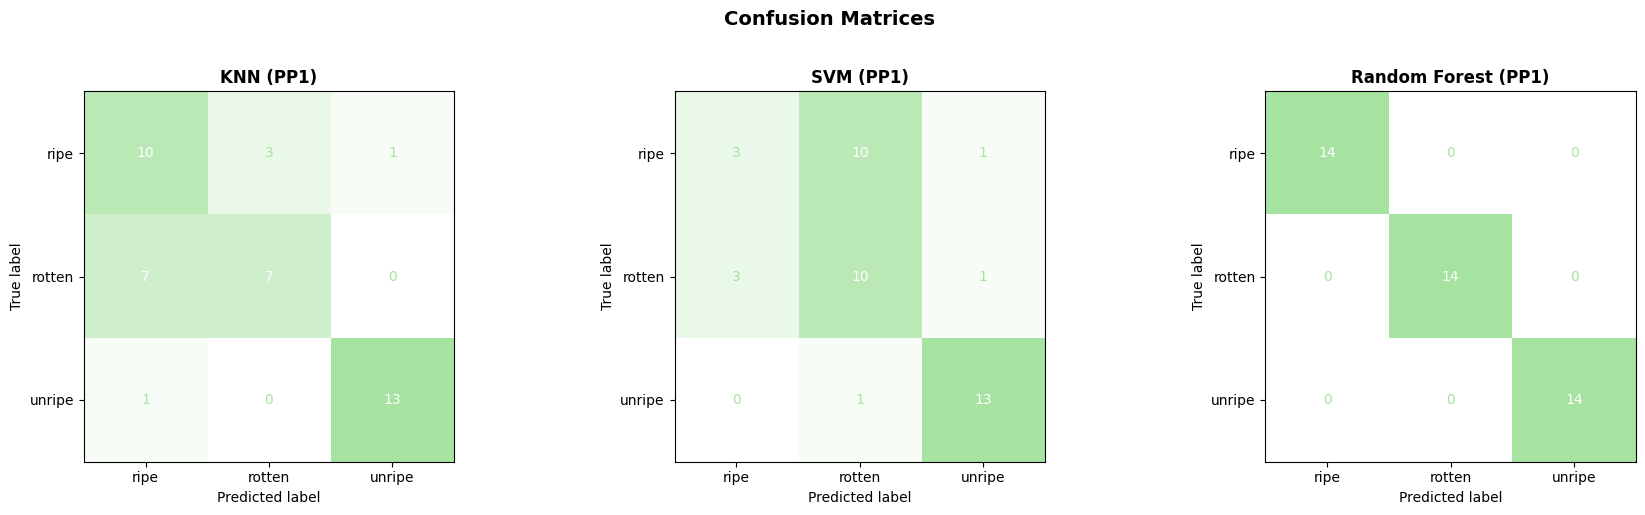

In [21]:
green_cmap = LinearSegmentedColormap.from_list("green", ["#ffffff", "#a6e3a1"])

def plot_confusion_matrices_side_by_side(results, title="Confusion Matrices"):
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
    
    for ax, (label, y_true, y_pred) in zip(axes, results):
        cm   = confusion_matrix(y_true, y_pred, labels=CLASSES)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
        disp.plot(cmap=green_cmap, ax=ax, colorbar=False)
        ax.set_title(label, fontweight="bold")
    
    plt.suptitle(title, fontweight="bold", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_confusion_matrices_side_by_side([
    ("KNN (PP1)",           y_test, y_pred_knn),
    ("SVM (PP1)",           y_test, y_pred_svm),
    ("Random Forest (PP1)", y_test, y_pred_rf),
])

---

<h2>Classification Report</h2>

In [22]:
print("=== KNN ===")
print(classification_report(y_test, y_pred_knn, target_names=CLASSES, zero_division=0))

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=CLASSES, zero_division=0))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=CLASSES, zero_division=0))


=== KNN ===
              precision    recall  f1-score   support

        ripe       0.56      0.71      0.62        14
      rotten       0.70      0.50      0.58        14
      unripe       0.93      0.93      0.93        14

    accuracy                           0.71        42
   macro avg       0.73      0.71      0.71        42
weighted avg       0.73      0.71      0.71        42

=== SVM ===
              precision    recall  f1-score   support

        ripe       0.50      0.21      0.30        14
      rotten       0.48      0.71      0.57        14
      unripe       0.87      0.93      0.90        14

    accuracy                           0.62        42
   macro avg       0.61      0.62      0.59        42
weighted avg       0.61      0.62      0.59        42

=== Random Forest ===
              precision    recall  f1-score   support

        ripe       1.00      1.00      1.00        14
      rotten       1.00      1.00      1.00        14
      unripe       1.00      

kode ini mencetak laporan klasifikasi lengkap (classification_report) untuk ketiga model secara berurutan, yang mencakup nilai presisi, recall, dan F1-score per kelas (ripe, rotten, unripe) beserta rata-rata makro dan berbobot. Laporan ini memberikan gambaran detail performa model pada masing-masing kelas, bukan hanya akurasi keseluruhan.

<h2>Perbandingan KNN vs SVM vs Random Forest (PP1)</h2>

In [23]:
df_hasil = pd.DataFrame({
    "Classifier": ["KNN", "SVM", "Random Forest"],
    "Accuracy" : [acc_knn,  acc_svm,  acc_rf],
    "Precision": [prec_knn, prec_svm, prec_rf],
    "Recall"   : [rec_knn,  rec_svm,  rec_rf],
    "F1-Score" : [f1_knn,   f1_svm,   f1_rf],
})
df_hasil = df_hasil.round(4)
df_hasil.to_csv("hasil_pp1.csv", index=False)
print("Tabel Perbandingan PP1:")
df_hasil


Tabel Perbandingan PP1:


,Classifier,Accuracy,Precision,Recall,F1-Score
0,KNN,0.7143,0.7280,0.7143,0.7123
1,SVM,0.6190,0.6143,0.6190,0.5893
2,Random Forest,1.0000,1.0000,1.0000,1.0000


kode ini menggabungkan hasil metrik evaluasi ketiga model ke dalam sebuah DataFrame perbandingan yang dibulatkan ke 4 desimal, lalu menyimpannya ke file hasil_pp1.csv. DataFrame ini memudahkan perbandingan kuantitatif antara KNN, SVM, dan Random Forest dalam satu tampilan tabel yang ringkas.

### Grafik Perbandingan Metrik

Cell ini memvisualisasikan perbandingan keempat metrik evaluasi (akurasi, presisi, recall, F1-score) untuk ketiga model dalam bentuk diagram batang berkelompok berwarna menggunakan matplotlib. Setiap batang diberi anotasi nilai numeriknya, sumbu Y dibatasi hingga 1.15 agar label tidak terpotong, dan grafik disimpan ke file grafik_pp1.png.

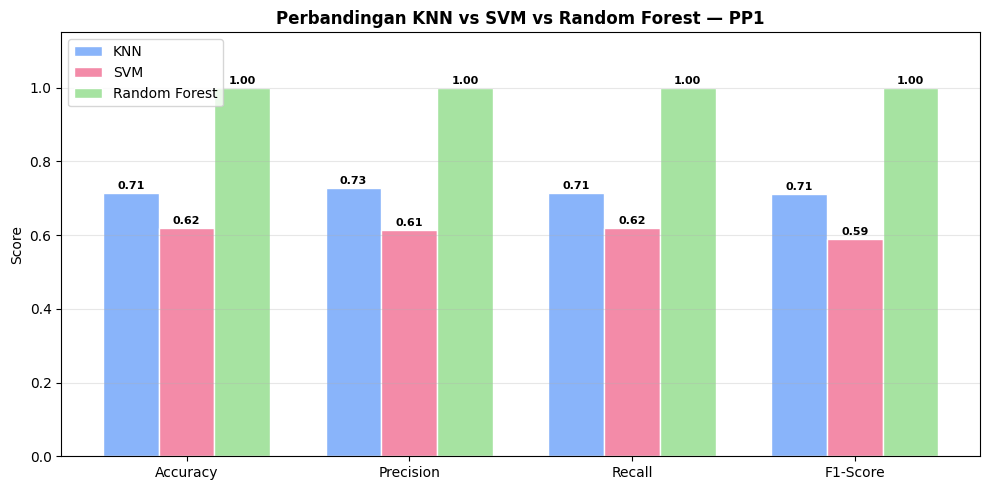

Grafik tersimpan sebagai grafik_pp1.png


In [24]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x       = np.arange(len(metrics))
width   = 0.25
colors  = ["#89b4fa", "#f38ba8", "#a6e3a1"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (clf, color) in enumerate(zip(["KNN", "SVM", "Random Forest"], colors)):
    vals = df_hasil[df_hasil["Classifier"] == clf][metrics].values.flatten()
    bars = ax.bar(x + i * width, vals, width, label=clf, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_title("Perbandingan KNN vs SVM vs Random Forest — PP1", fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("grafik_pp1.png", dpi=120, bbox_inches="tight")
plt.show()
print("Grafik tersimpan sebagai grafik_pp1.png")


---

In [25]:
best = df_hasil.loc[df_hasil["Accuracy"].idxmax()]
print("=" * 40)
print("  HASIL TERBAIK PP1")
print("=" * 40)
print(f"  Classifier : {best['Classifier']}")
print(f"  Accuracy   : {best['Accuracy']:.4f}")
print(f"  Precision  : {best['Precision']:.4f}")
print(f"  Recall     : {best['Recall']:.4f}")
print(f"  F1-Score   : {best['F1-Score']:.4f}")
print("=" * 40)


  HASIL TERBAIK PP1
  Classifier : Random Forest
  Accuracy   : 1.0000
  Precision  : 1.0000
  Recall     : 1.0000
  F1-Score   : 1.0000


kode ini mengidentifikasi model dengan akurasi tertinggi dari DataFrame perbandingan menggunakan idxmax(), lalu mencetak ringkasan hasil terbaiknya (nama classifier beserta nilai akurasi, presisi, recall, dan F1-score) dalam format yang bersih dan mudah dibaca sebagai kesimpulan akhir dari seluruh eksperimen PP1.

<h2>Analisis PP1</h2>

*(Isi setelah melihat hasil eksperimen)*

Jelaskan:
1. Classifier mana yang terbaik pada PP1 dan mengapa
2. Apakah ekualisasi histogram membantu menonjolkan tekstur kematangan pisang
3. Kelas mana yang paling sulit diklasifikasikan (lihat confusion matrix)


sdcbasbccja